## 1 Probability estimation

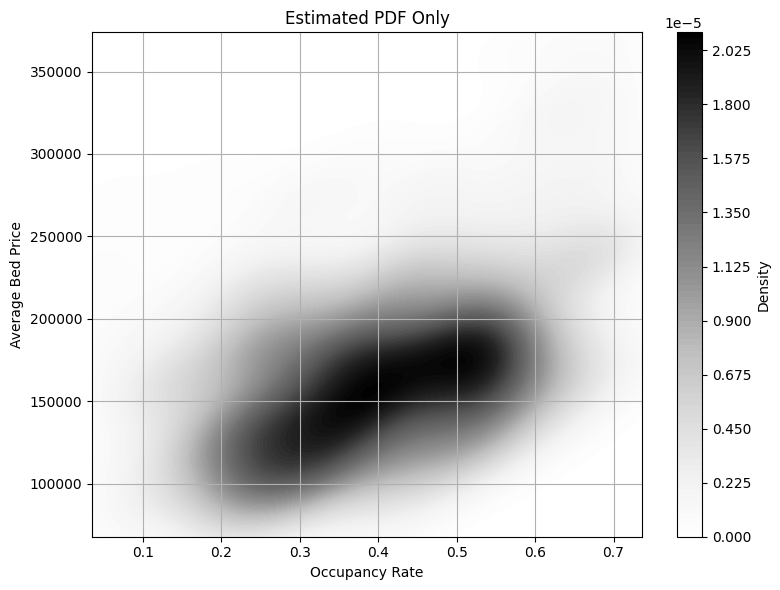

In [2]:
import pandas as pd

from scripts.plot import plot_density_analysis
from scripts.pdf_estimation import create_pdf_estimation

# Load and process data
daily_df = pd.read_csv('data/daily_aggregated_data.csv', parse_dates=['stay_date'])

x = daily_df['occupancy_rate'].values
y = daily_df['avg_bed_rate'].values

# Create PDF estimation
kde, X, Y, Z = create_pdf_estimation(x, y)

# #plot both
# plot_density_analysis(
#     df=daily_df, 
#     x_col='occupancy_rate', 
#     y_col='avg_bed_rate', 
#     pdf_data=(X, Y, Z), 
#     title="2D KDE with Data and PDF"
#     )

# #plot data only
# plot_density_analysis(
#     df=daily_df, 
#     x_col='occupancy_rate', 
#     y_col='avg_bed_rate', 
#     title="Original Data Only"
#     )

#plot PDF only
plot_density_analysis(
    pdf_data=(X, Y, Z), 
    title="Estimated PDF Only"
)

In [3]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid

def extract_conditional_pdf(X, Y, Z, occupancy_rate):
    """
    Extract 1D conditional PDF of prices given a specific occupancy rate.
    
    Parameters:
    - X, Y, Z: 2D PDF grid (occupancy, price, density)
    - occupancy_rate: specific occupancy rate to condition on
    
    Returns:
    - prices: 1D array of price values
    - conditional_pdf: 1D conditional probability density for prices
    """
    # Get the occupancy and price grids
    occupancy_grid = X[0, :]  # First row contains occupancy values
    price_grid = Y[:, 0]      # First column contains price values
    
    # Check if occupancy_rate is within bounds
    if occupancy_rate < occupancy_grid.min() or occupancy_rate > occupancy_grid.max():
        raise ValueError(f"Occupancy rate {occupancy_rate} is outside the data range "
                        f"[{occupancy_grid.min():.3f}, {occupancy_grid.max():.3f}]")
    
    # Find the nearest occupancy indices or interpolate
    if occupancy_rate in occupancy_grid:
        # Exact match
        occ_idx = np.where(occupancy_grid == occupancy_rate)[0][0]
        conditional_density = Z[:, occ_idx]
    else:
        # Interpolate between nearest occupancy values
        interp_func = interp1d(occupancy_grid, Z, axis=1, kind='linear')
        conditional_density = interp_func(occupancy_rate)
    
    # Normalize to make it a proper 1D PDF
    dx = price_grid[1] - price_grid[0]  # Assuming uniform grid
    integral = np.trapz(conditional_density, dx=dx)
    
    if integral > 0:
        conditional_pdf = conditional_density / integral
    else:
        raise ValueError("Invalid conditional density - integral is zero or negative")
    
    return price_grid, conditional_pdf

def plot_conditional_pdf(prices, conditional_pdf, occupancy_rate, figsize=(8, 5)):
    """
    Plot the 1D conditional PDF.
    
    Parameters:
    - prices: 1D array of price values
    - conditional_pdf: 1D conditional probability density
    - occupancy_rate: the conditioning occupancy rate
    - figsize: figure size tuple
    """
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=figsize)
    plt.fill_between(prices, conditional_pdf, alpha=0.7, color='grey', 
                     label=f'PDF | Occupancy = {occupancy_rate:.2f}')
    plt.plot(prices, conditional_pdf, color='black', linewidth=2)
    
    plt.xlabel('Average Bed Price')
    plt.ylabel('Probability Density')
    plt.title(f'Conditional PDF of Price | Occupancy Rate = {occupancy_rate:.2f}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def calculate_price_quantile(prices, conditional_pdf, quantile):
    """
    Calculate the price corresponding to a given quantile from the conditional PDF.
    
    Parameters:
    - prices: 1D array of price values
    - conditional_pdf: 1D conditional probability density
    - quantile: desired quantile (0.0 to 1.0, e.g., 0.5 for median)
    
    Returns:
    - quantile_price: price at the specified quantile
    """
    if not 0 <= quantile <= 1:
        raise ValueError("Quantile must be between 0 and 1")
    
    # Calculate CDF using cumulative integration
    dx = prices[1] - prices[0]  # Assuming uniform grid
    cdf = cumulative_trapezoid(conditional_pdf, dx=dx, initial=0)
    
    # Normalize CDF to ensure it ends at 1
    cdf = cdf / cdf[-1]
    
    # Interpolate to find the price at the desired quantile
    if quantile == 0:
        return prices[0]
    elif quantile == 1:
        return prices[-1]
    else:
        interp_func = interp1d(cdf, prices, kind='linear')
        return float(interp_func(quantile))

In [4]:
# Example usage: Get conditional PDF for specific occupancy rate
target_occupancy = 0.75  # 75% occupancy

try:
    # Extract conditional PDF
    prices, cond_pdf = extract_conditional_pdf(X, Y, Z, target_occupancy)
    
    # Plot the conditional PDF
    plot_conditional_pdf(prices, cond_pdf, target_occupancy)
    
    # Calculate key quantiles
    quantiles_to_check = [0.05, 0.25, 0.5, 0.73]
    print(f"\nPrice quantiles for occupancy rate {target_occupancy:.2f}:")
    print("-" * 50)
    
    for q in quantiles_to_check:
        price = calculate_price_quantile(prices, cond_pdf, q)
        print(f"{q*100:4.0f}th percentile: ${price:6.2f}")
        
except ValueError as e:
    print(f"Error: {e}")
    print("Available occupancy range:", X[0, :].min(), "to", X[0, :].max())

Error: Occupancy rate 0.75 is outside the data range [0.035, 0.737]
Available occupancy range: 0.0351 to 0.7368


Occupancy rate 0.9 is outside data range


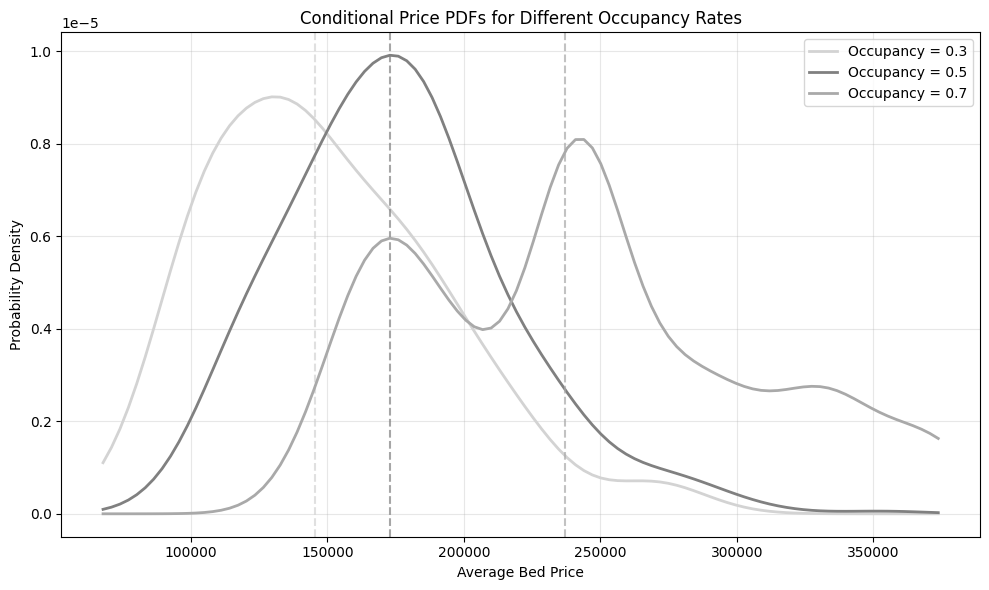


Median prices by occupancy rate:
-----------------------------------
Occupancy 0.3: $145289.79
Occupancy 0.5: $172854.76
Occupancy 0.7: $237172.83
Occupancy 0.9: Out of range


In [5]:
# Compare conditional PDFs for different occupancy rates
import matplotlib.pyplot as plt

occupancy_rates = [0.3, 0.5, 0.7, 0.9]
colors = ['lightgrey', 'grey', 'darkgrey', 'black']

plt.figure(figsize=(10, 6))

for i, occ_rate in enumerate(occupancy_rates):
    try:
        prices, cond_pdf = extract_conditional_pdf(X, Y, Z, occ_rate)
        plt.plot(prices, cond_pdf, color=colors[i], linewidth=2, 
                label=f'Occupancy = {occ_rate:.1f}')
        
        # Also show median price for each occupancy
        median_price = calculate_price_quantile(prices, cond_pdf, 0.5)
        plt.axvline(median_price, color=colors[i], linestyle='--', alpha=0.7)
        
    except ValueError:
        print(f"Occupancy rate {occ_rate} is outside data range")

plt.xlabel('Average Bed Price')
plt.ylabel('Probability Density')
plt.title('Conditional Price PDFs for Different Occupancy Rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table of median prices
print("\nMedian prices by occupancy rate:")
print("-" * 35)
for occ_rate in occupancy_rates:
    try:
        prices, cond_pdf = extract_conditional_pdf(X, Y, Z, occ_rate)
        median_price = calculate_price_quantile(prices, cond_pdf, 0.5)
        print(f"Occupancy {occ_rate:.1f}: ${median_price:6.2f}")
    except ValueError:
        print(f"Occupancy {occ_rate:.1f}: Out of range")

=== OCCUPANCY RANGE ANALYSIS ===
Original data occupancy range: 0.035 to 0.737
Grid occupancy range: 0.035 to 0.737
Grid shape: (100, 100)


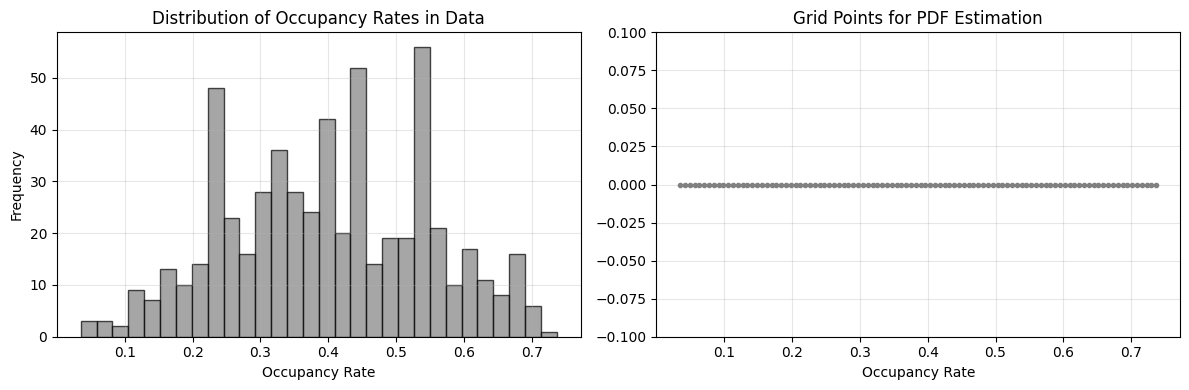


Some sample occupancy grid values:
First 10: [0.0351     0.04218788 0.04927576 0.05636364 0.06345152 0.07053939
 0.07762727 0.08471515 0.09180303 0.09889091]
Last 10:  [0.67300909 0.68009697 0.68718485 0.69427273 0.70136061 0.70844848
 0.71553636 0.72262424 0.72971212 0.7368    ]

Percentiles of actual data:
90th percentile: 0.597
95th percentile: 0.649
99th percentile: 0.702
Maximum value:   0.737


In [6]:
# Debug: Check the actual occupancy range in your data
print("=== OCCUPANCY RANGE ANALYSIS ===")
print(f"Original data occupancy range: {daily_df['occupancy_rate'].min():.3f} to {daily_df['occupancy_rate'].max():.3f}")
print(f"Grid occupancy range: {X[0, :].min():.3f} to {X[0, :].max():.3f}")
print(f"Grid shape: {X.shape}")

# Show distribution of occupancy rates
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of actual data
ax1.hist(daily_df['occupancy_rate'], bins=30, color='grey', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Occupancy Rate')
ax1.set_ylabel('Frequency') 
ax1.set_title('Distribution of Occupancy Rates in Data')
ax1.grid(True, alpha=0.3)

# Show the grid points
ax2.plot(X[0, :], np.zeros_like(X[0, :]), 'o', color='grey', markersize=3)
ax2.set_xlabel('Occupancy Rate')
ax2.set_title('Grid Points for PDF Estimation')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.1, 0.1)

plt.tight_layout()
plt.show()

print(f"\nSome sample occupancy grid values:")
print(f"First 10: {X[0, :10]}")
print(f"Last 10:  {X[0, -10:]}")
print(f"\nPercentiles of actual data:")
print(f"90th percentile: {np.percentile(daily_df['occupancy_rate'], 90):.3f}")
print(f"95th percentile: {np.percentile(daily_df['occupancy_rate'], 95):.3f}")
print(f"99th percentile: {np.percentile(daily_df['occupancy_rate'], 99):.3f}")
print(f"Maximum value:   {daily_df['occupancy_rate'].max():.3f}")